# Fine-tuning TinyLlama with LoRA

Loads TinyLlama-1.1B-Chat, fine-tunes it with LoRA on the curated training data, then exports the merged model to GGUF and registers it with Ollama for serving.

## Step 1: Load Configuration

In [ ]:
import sys
from pathlib import Path

RUNEBOOK_ROOT = Path.cwd()  # notebook 01's clone cell already chdir'd here
if str(RUNEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(RUNEBOOK_ROOT))

from src.trainer import OllamaTrainer

trainer = OllamaTrainer(RUNEBOOK_ROOT / "config/training_config.yaml")
print(trainer.get_config_summary())

## Step 2: Run LoRA Fine-tuning

This trains on the single T4 GPU with the bank transaction dataset (800 train examples, 8 epochs, gradient accumulation 2 → effective batch 16). ~400 optimization steps, ~4-5 minutes.

In [ ]:
# Colab's /content is the ephemeral runtime disk (no Databricks 500MB workspace file limit here)
trainer.output_dir = Path("/content/finetuning_output")
trainer.output_dir.mkdir(parents=True, exist_ok=True)

result = trainer.train()

print(f"Status: {result['status']}")
print(f"Final loss: {float(result['final_loss']) if isinstance(result['final_loss'], str) else result['final_loss']}")
print(f"Merged model saved to: {result['merged_dir']}")
print(f"LoRA adapter saved to: {result['adapter_dir']}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss
25,2.027252,1.887017
50,1.131280,0.887325
75,0.578781,0.447661
100,0.293975,0.248132
125,0.124911,0.168218
150,0.153136,0.118870
175,0.099287,0.099556
200,0.068691,0.095157
225,0.043365,0.087788
250,0.083567,0.087501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Status: completed
Final loss: 0.024460650980472565
Merged model saved to: /content/finetuning_output/merged
LoRA adapter saved to: /content/finetuning_output/adapter


## Step 3: Plot the Training Loss Curve

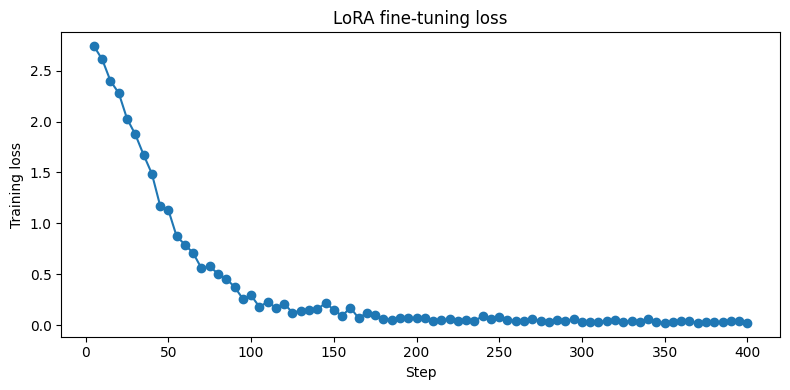

In [ ]:
import matplotlib.pyplot as plt

steps = [entry["step"] for entry in result["log_history"] if "loss" in entry]
losses = [entry["loss"] for entry in result["log_history"] if "loss" in entry]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker="o")
plt.xlabel("Step")
plt.ylabel("Training loss")
plt.title("LoRA fine-tuning loss")
plt.tight_layout()
plt.show()

## Step 4: Export to GGUF

Ollama can only serve GGUF models, so the merged fp16 model is converted via llama.cpp's `convert_hf_to_gguf.py`.

In [ ]:
from src.ollama_export import convert_to_gguf, create_ollama_model

merged_dir = Path(result["merged_dir"])
gguf_path = merged_dir / "model.gguf"

convert_to_gguf(
    merged_model_dir=merged_dir,
    output_gguf=gguf_path,
    llama_cpp_dir=Path("/content/llama.cpp"),
    outtype="q8_0",
)
print(f"\nGGUF model written to {gguf_path}")


GGUF model written to /content/finetuning_output/merged/model.gguf


## Step 5: Register the Model with Ollama

In [ ]:
OLLAMA_MODEL_NAME = "tinyllama-finetuned:latest"

create_ollama_model(
    name=OLLAMA_MODEL_NAME,
    gguf_path=gguf_path,
    system_prompt="You are a helpful assistant fine-tuned on domain-specific instructions.",
)
print(f"\nRegistered '{OLLAMA_MODEL_NAME}' with Ollama")


Registered 'tinyllama-finetuned:latest' with Ollama


## Step 6: Sanity-check the Served Model

In [ ]:
import requests

test_prompt = """Categorize the following bank transaction based on its description.
RAPPI*RAPPI COL CHAPINERO - $52,000 COP - 2024-06-15 21:10"""

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": OLLAMA_MODEL_NAME,
        "prompt": test_prompt,
        "stream": False,
    },
    timeout=5*60,
)
response.raise_for_status()
print("Prompt:", test_prompt.strip())
print("\n--- Model Response ---")
print(response.json()["response"])

## Fine-tuning & Deployment Complete

The fine-tuned model is trained, exported, and being served via Ollama. Next: run `04_evaluation.ipynb` to measure quality against the baseline.